# Chatbot Reading Existing Memories

In [4]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore
import os

In [6]:
load_dotenv()

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)


In [12]:
    # ----------------------------
# 1) Create LTM store + seed memories (done BEFORE running the graph)
# ----------------------------
store = InMemoryStore()

user_id = "u1"

# Store user details as a single blob (simple for teaching)
# You can also split into multiple records; this keeps it easy.
user_details = ("user", user_id, "details")

store.put(user_details, "profile_1", {"data": "Name: Imran Butt"})
store.put(user_details, "profile_2", {"data": "Profession: Student Also Learning AI"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [11]:
# ----------------------------
# 2) System prompt template (your prompt)
# ----------------------------
SYSTEM_PROMPT_TEMPLATE = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Imran...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}
"""

In [ ]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config["configurable"]["user_id"]

    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)

    # Convert memory items into a string blob for {user_details_content}
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""  # prompt says it may be empty

    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(
        user_details_content=user_details_content
    )

    system_msg = SystemMessage(content=system_prompt)

    response = llm.invoke([system_msg] + state["messages"])
    return {"messages": [response]}

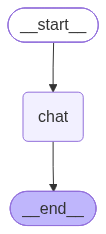

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [15]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

**Sure, Imran—here’s a quick, simple rundown of generative AI (Gen AI):**

---

### What is Generative AI?
- **Definition:** A type of artificial intelligence that learns patterns from existing data (like text, images, or sound) and then creates *new* content that looks or sounds similar.
- **How it works (high‑level):**
  1. **Training:** Feed a huge dataset to a model (e.g., a neural network). The model adjusts its internal parameters to capture statistical regularities.
  2. **Generation:** Give the trained model a prompt or seed, and it samples from what it has learned to produce fresh output.

---

### Everyday Analogy
Think of a **mimic artist** who studies thousands of paintings. After enough practice, the artist can paint a brand‑new picture that follows the same style, even though that exact picture never existed before.

---

### Core Building Blocks (in Python terms)
```python
from transformers import pipeline

# 1️⃣ Load a pre‑trained generative model (e.g., GPT‑2 for text)

In [16]:
# ----------------------------
# 4) Run it (provide user_id in config)
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is AI."}]},
    config,
)

print(result["messages"][-1].content)

Hi Imran,

**Artificial Intelligence (AI)** is the field of computer science that creates systems capable of performing tasks that normally require human intelligence—such as learning, reasoning, perception, and decision‑making.

At a high level, AI can be split into:

| Category | What it does | Typical Python tools |
|----------|--------------|----------------------|
| **Machine Learning (ML)** | Learns patterns from data to make predictions | `scikit‑learn`, `pandas` |
| **Deep Learning** | Uses multi‑layer neural networks for complex patterns (images, speech) | `TensorFlow`, `PyTorch` |
| **Natural Language Processing (NLP)** | Understands or generates human language | `spaCy`, `transformers` |
| **Computer Vision** | Interprets visual data | `opencv`, `torchvision` |

### Tiny Python example (ML with scikit‑learn)

```python
# A very simple AI that predicts whether a fruit is an apple or orange
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Features: [wei

# Chatbot Creating New Memories

In [17]:
from dotenv import load_dotenv
load_dotenv()

import uuid
from typing import List
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableConfig

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [18]:
# ----------------------------
# 1) LTM store
# ----------------------------
store = InMemoryStore()

In [19]:
extractor_llm  = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [20]:

class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: List[str] = Field(default_factory=list, description="Atomic user memories to store")

In [22]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [23]:
# ----------------------------
# 3) Graph: START -> remember -> END
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke(
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

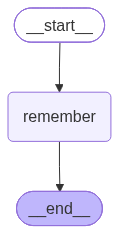

In [24]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [25]:
# ----------------------------
# 4) Demo
# ----------------------------
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Imran Butt"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [26]:
res = graph.invoke({"messages": [{"role": "user", "content": "I love learning about AI"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [29]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [27]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [30]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Imran Butt.
The user loves learning about AI.
The user prefers Python as their favorite programming language.
User's favorite programming language is Python.
